In [1]:
%load_ext autoreload
%autoreload 2

# Torchvision Maskrcnn on Volpy Data 

Created by Changjia Cai, Erik Thompson, and Manuel Paez

Date Created: August 28th, 2024

Date Updated: July 7th, 2025

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage.color import rgb2gray, gray2rgb
import torch
from torch.optim.lr_scheduler import CyclicLR
from torch.utils.data import Dataset, DataLoader
from torchvision import tv_tensors

from config import Config
from model import get_model_instance_segmentation, mrcnn_inference, thresholded_predictions 
from neurons import NeuronsDataset, collate_fn, data_transform, train_one_epoch, validate
from utils import ScaleImage, nf_match_neurons_in_binary_masks, normalize_image, vp_load_image 
from visualize import apply_masks, draw_boxes

In [3]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


## Inspect VolPy data

There are 24 datasets in total, 3 types of different voltage imaging datasets recorded from mouse L1 cortex (L1), mouse hippocampus (HPC), and zebrafish tegmental area (TEG). Set up the image directories from https://zenodo.org/records/4515768 as follows:

    volpy_training_data/
        images/
            HPC.29.04.npz
            ...
        masks/
            HPC.29.04_mask.npz
            ...        
            
The following `data_dir` variable should be directed to `volpy_training_data`

In [4]:
data_dir = r'/mnt/home/mpaez/ceph/volpy_training_data/' #changeable
image_dir = data_dir + 'images/' 
image_path_list = list(sorted(os.listdir(os.path.join(data_dir, "images"))))
mask_path_list = list(sorted(os.listdir(os.path.join(data_dir, "masks"))))

In [5]:
# Load one Image and Masks
dat_ind = 12
data_path = image_path_list[dat_ind]  
mask_path = mask_path_list[dat_ind] 
print(f'image name: {data_path}')
print(f'mask name: {mask_path}')

data_loaded = np.load(data_dir + 'images/' + data_path)
masks_loaded = np.load(data_dir + 'masks/' + mask_path, allow_pickle=True)
image = data_loaded['img']
masks = masks_loaded['mask']
image_gray = rgb2gray(image)
num_masks = len(masks)
print(f'image shape: {image.shape}, number of masks: {num_masks}')

image_tensor = torch.from_numpy(image).permute(2,0,1)
image_tensor = tv_tensors.Image(image_tensor)

image name: L1.00.00.npz
mask name: L1.00.00_mask.npz
image shape: (512, 128, 3), number of masks: 79


Plot the Volpy Segmentation (with Parameters initialized as below)

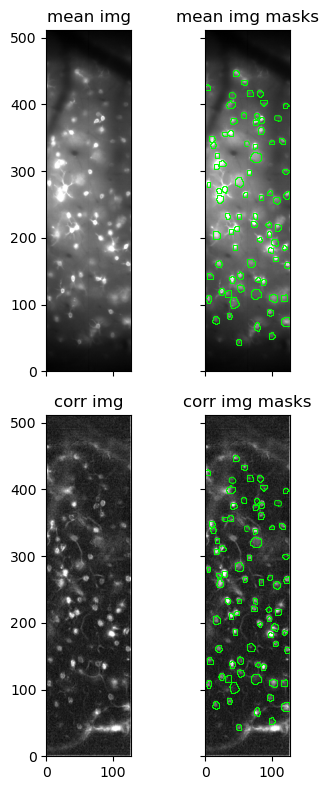

In [6]:
max_v = 99
outline_color = 'lime'
outline_width = 0.75
figsize = (4,8)

f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=figsize, sharex=True, sharey=True)  # w/h
# mean img
ax1.imshow(image[:,:,1], cmap='gray', vmax=np.percentile(image[:,:,1], max_v))
ax1.set_title('mean img')
ax2.imshow(image[:,:,1], cmap='gray', vmax=np.percentile(image[:,:,1], max_v))
for mask in masks:
    ax2.plot(mask['all_points_x'], mask['all_points_y'], 
             color=outline_color, linewidth=outline_width)
ax2.set_title('mean img masks')

# corr img
ax3.imshow(image[:,:,2], cmap='gray', vmax=np.percentile(image[:,:,2], max_v))
ax3.set_title('corr img')
ax4.imshow(image[:,:,2], cmap='gray', vmax=np.percentile(image[:,:,2], max_v))
for mask in masks:
    ax4.plot(mask['all_points_x'], mask['all_points_y'], 
             color=outline_color, linewidth=outline_width)
ax4.set_title('corr img masks')
plt.xlim([0, image.shape[1]-1])
plt.ylim([0, image.shape[0]-1])
plt.tight_layout()

### Define the Dataset

Building on the standard `torch.utils.data.Dataset`class, we use 'NeuronsDataset' from neurons.py. The  `__getitem__` method of this class should return an `image` and a `target` dictionary delineating the different objects (box/mask) in the image:

    image: torchvision.tv_tensors.Image of shape [3, H, W]: can be a pure tensor, or a PIL Image of size (H, W)
    target: a dict containing the following keys
        masks : torchvision uint8 binary masks for each object (N,H,W) (N masks)
        boxes (bounding boxes)  (nx4)
        labels (int) label for each bounding box (note 0 is background, so if you have no bg, start with 1)
        image_id (int) unique image id
        area (float) area of bounding box 
        iscrowd (uint8) instances with `iscrowd=True` will be ignored during evaluation 

The 'data_transform' function from neurons.py should return a training pipeline for training. 
For windows, set the number of workers to 0. Otherwise, set to 4+

#### Check Dataset
Make sure everything is working

In [8]:
num_torch_workers = 0
volpy_data = NeuronsDataset(data_dir, data_transform(train=True))
volpy_dataloader = torch.utils.data.DataLoader(volpy_data,
                                               batch_size=6,
                                               shuffle=True,
                                               num_workers=num_torch_workers,
                                               collate_fn=collate_fn)

print(len(volpy_data))

session_ind = 17
orig_image, orig_image_path = vp_load_image(image_dir, image_path_list, session_ind) # orig data and masks
dataset_image, dataset_target = volpy_data[session_ind] # data after transformation

summary_mn = gray2rgb(normalize_image(dataset_image[1,:,:]))
summary_corr = gray2rgb(normalize_image(dataset_image[2,:,:]))
data_masks = dataset_target['masks']
data_boxes = dataset_target['boxes']

24


#### Visualize Transformed Data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.254].


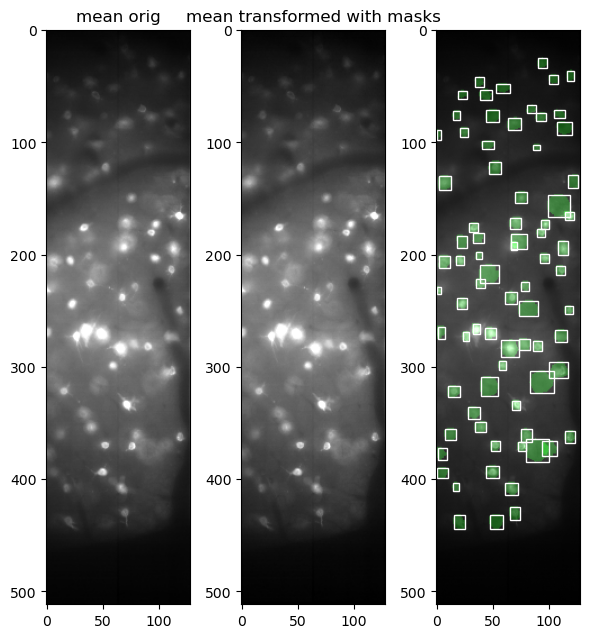

In [9]:
mask_color = (0, 1, 0)
plot_box = True
box_color = 'white'
alpha = 0.001

masked_mn_vp = apply_masks(summary_mn, data_masks, mask_color, alpha=alpha)
f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(6, 12))
ax1.imshow(orig_image[:,:,0], cmap='gray', vmax=np.percentile(orig_image[:,:,0], 99.5))
ax1.set_title('mean orig')
ax2.imshow(summary_mn[:, :, 0], cmap='gray',  vmax=np.percentile(summary_mn, 99.5))
ax2.set_title('mean transformed')
ax3.imshow(masked_mn_vp)
ax2.set_title('mean transformed with masks')
if plot_box:
    ax3, rects = draw_boxes(data_boxes, color=box_color, line_width=1, ax=ax3)  
plt.tight_layout()

#### Check Dataloader
Note: Dataloader is an iterable

In [10]:
batch_images, batch_targets = next(iter(volpy_dataloader))

# standard way of extracting images and targets for a batch into a list
batch_images = list(image for image in batch_images)
batch_targets = [{k: v for k, v in t.items()} for t in batch_targets]

# check one sample
batch_ind = 0
batch_item_target = batch_targets[batch_ind]
batch_item_image = batch_images[batch_ind]
batch_item_id = batch_item_target['image_id']

# extract original image so we can compare
image_orig, image_orig_path = vp_load_image(image_dir, image_path_list, batch_item_id)

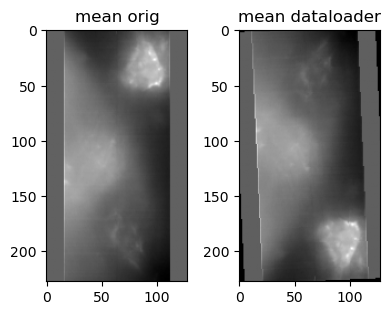

In [12]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(4,8))
ax1.imshow(image_orig[:,:,0], cmap='gray')
ax1.set_title('mean orig')
ax2.imshow(batch_item_image[0,:,:], cmap='gray')
ax2.set_title('mean dataloader')
plt.tight_layout()

## Training and Volpy

### Train and Validation Sets


In [13]:
# use our dataset and defined transformations
"""
Config has the following thing set:
    DATASET_PATH = "/mnt/home/mpaez/ceph/volpy_training_data/" # Default path, can be overridden by args
    MODEL_SAVE_DIR = '/mnt/home/mpaez/ceph/volpy_models'
    NUM_CLASSES = 2  # Background + neuron
    IMAGES_PER_GPU = 2
    NUM_TEST = 8
    BATCH_SIZE = 2 #
    NUM_EPOCHS = 100 #Test Samples
    MAX_LR = 0.005 
    NUM_TORCH_WORKERS = 0 if torch.cuda.is_available() else 0
    DETECTION_MIN_CONFIDENCE = 0.7
    PRINT_FREQ = 1 # Print frequency during training (in epochs)
    SAVE_FREQ = 20 # Save frequency during training (in epochs)
    # --- Checkpoints ---
    LOGS_DIR = "/mnt/home/mpaez/ceph/volpy_training_data/"
"""
config = Config()
print(f"Using device: {device}")

num_test = config.NUM_TEST

print("Loading datasets...")
dataset_train = NeuronsDataset(data_dir, data_transform(train=True))
dataset_val = NeuronsDataset(data_dir, data_transform(train=False))

dataset_train.print_image_filenames()

indices = [4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 18, 19, 20, 22, 23, 0, 1, 2, 3, 12, 13, 14, 21]
dataset_train = torch.utils.data.Subset(dataset_train, indices[:-num_test])
dataset_val = torch.utils.data.Subset(dataset_val, indices[-num_test:])
# here we select two thirds of datasets for training, one third of datasets for testing
# we make sure each type of datasets (L1, TEG, HPC) has at least one dataset for testing

print(f'training sets: {indices[:-num_test]}')
print(f'test sets: {indices[-num_test:]}')

data_loader_train = DataLoader(dataset_train, batch_size=config.BATCH_SIZE, 
                    shuffle=True, num_workers=config.NUM_TORCH_WORKERS, 
                    collate_fn=collate_fn)

data_loader_val = DataLoader(dataset_val, batch_size=1,
                    shuffle=False, num_workers=config.NUM_TORCH_WORKERS,
                    collate_fn=collate_fn)

# print(f"Original dataset size: {num_samples}")
print(f"Training set size:   {len(dataset_train)}")
print(f"Validation set size: {len(dataset_val)}")

Using device: cuda
Loading datasets...
HPC.29.04.npz
HPC.29.06.npz
HPC.32.01.npz
HPC.38.03.npz
HPC.38.05.npz
HPC.39.03.npz
HPC.39.04.npz
HPC.39.07.npz
HPC.48.01.npz
HPC.48.05.npz
HPC.48.07.npz
HPC.48.08.npz
L1.00.00.npz
L1.01.00.npz
L1.01.35.npz
L1.02.00.npz
L1.02.80.npz
L1.03.00.npz
L1.03.35.npz
L1.04.00.npz
L1.04.50.npz
TEG.01.02.npz
TEG.02.01.npz
TEG.03.01.npz
training sets: [4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 18, 19, 20, 22, 23]
test sets: [0, 1, 2, 3, 12, 13, 14, 21]
Training set size:   16
Validation set size: 8


### Model
We use a model pre-trained on the coc dataset

In [14]:
model = get_model_instance_segmentation(config.NUM_CLASSES)
model.to(device)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         

### Optimizer/lr scheduler

In [15]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=config.MAX_LR, momentum=0.9, weight_decay=0.0001) 
lr_scheduler = CyclicLR(optimizer, 
                     base_lr = 0.000001,     # Initial learning rate which is the lower boundary in the cycle for each parameter group
                     max_lr = config.MAX_LR,       # 0.003 Upper learning rate boundaries in the cycle for each parameter group
                     step_size_up = 3,     # Number of training iterations in the increasing half of a cycle
                     step_size_down = 7,
                     mode = "triangular2")

#### Training the Network

In [16]:
model_save_dir = '/mnt/home/mpaez/ceph/volpy_models'

all_train_losses, all_val_losses, all_lrs = [], [], []
print(f"**TRAIN {config.NUM_EPOCHS} epochs. PRINT every {config.PRINT_FREQ} epoch(s). "
          f"SAVE every {config.SAVE_FREQ} epoch(s).**")

num_train = len(dataset_train)
num_val = len(dataset_val)

print(f"**TRAIN {config.NUM_EPOCHS} epochs. SAVE every {config.SAVE_FREQ} epoch(s).**")
print("-" * 30)


for epoch in range(config.NUM_EPOCHS):
    # train_one_epoch sets model to train mode
    train_loss = train_one_epoch(model, optimizer, data_loader_train, device, epoch, config.PRINT_FREQ)
        
    # validate function handles model mode internally now
    val_loss = validate(model, data_loader_val, device, epoch)
        
    # Set model back to eval mode after validation, which is good practice
    model.eval()

    all_train_losses.append(train_loss)
    all_val_losses.append(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    all_lrs.append(current_lr)
        
    lr_scheduler.step()

    print(f"Epoch {epoch+1}/{config.NUM_EPOCHS} -> Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.6f}")

    if (epoch + 1) % config.SAVE_FREQ == 0:
        model_fname = f'mrcnn_epoch_{epoch+1}.pt'
        model_path = os.path.join(config.MODEL_SAVE_DIR, model_fname)
        torch.save(model.state_dict(), model_path)
        print(f"\t -> Model saved to {model_path}")
    
history = {'train_loss': all_train_losses, 'val_loss': all_val_losses, 'lr': all_lrs}
torch.save(history, os.path.join(config.MODEL_SAVE_DIR, 'volpy_train_history.pt'))
print("\nDONE!")

**TRAIN 100 epochs. PRINT every 1 epoch(s). SAVE every 20 epoch(s).**
**TRAIN 100 epochs. SAVE every 20 epoch(s).**
------------------------------


Epoch 1 [val]: 100%|██████████| 8/8 [00:00<00:00, 14.78it/s]


Epoch 1/100 -> Train Loss: 4.0335, Val Loss: 4.0664, LR: 0.000001


Epoch 2 [val]: 100%|██████████| 8/8 [00:00<00:00, 22.71it/s]


Epoch 2/100 -> Train Loss: 2.3859, Val Loss: 2.2610, LR: 0.001667


...

Epoch 98/100 -> Train Loss: 1.0125, Val Loss: 1.1512, LR: 0.000005


Epoch 99 [val]: 100%|██████████| 8/8 [00:00<00:00, 23.73it/s]


Epoch 99/100 -> Train Loss: 0.9494, Val Loss: 1.1953, LR: 0.000004


Epoch 100 [val]: 100%|██████████| 8/8 [00:00<00:00, 22.01it/s]


Epoch 100/100 -> Train Loss: 0.9730, Val Loss: 1.1806, LR: 0.000002
	 -> Model saved to /mnt/home/mpaez/ceph/volpy_models/mrcnn_epoch_100.pt

DONE!


#### Plot Loss Function

In [ ]:
plt.plot(np.array(all_train_losses), color='blue', marker='.', label='train')
plt.plot(np.array(all_val_losses), color='red', marker='.', label='validation')
plt.legend();
plt.xlabel('epoch')
plt.ylabel('net loss')
plt.title('loss function across different epochs')
plt.grid()

#### Plot Learning Rate vs Epoch

In [ ]:
plt.plot(all_lrs, marker='.')
plt.xlabel('epoch')
plt.ylabel('learning rate')
plt.title('learning rate across different epochs')

## Inference using Test Set

In [ ]:
# pull original data 
idx = 4
val_set = np.array([0, 1, 2, 3, 12, 13, 14, 21])
volpy_inference_dataset = NeuronsDataset(data_dir, data_transform(train=False))
vp_im, vp_target = volpy_inference_dataset[val_set[idx]]
summary_mn = gray2rgb(normalize_image(vp_im[1,:,:]))
summary_corr = gray2rgb(normalize_image(vp_im[2,:,:]))
data_masks = vp_target['masks']
data_boxes = vp_target['boxes']

#### Run Inference on One Dataset 

In [ ]:
# run inference on one dataset
eval_transform = data_transform(train=False)
model.eval()
with torch.no_grad():
    x = eval_transform(vp_im)
    x = x.to(device)
    predictions = model([x, ])
    pred = predictions[0]

# prediction score range
print(f'prediction scores: {pred["scores"]}')

In [ ]:
thresh = 0.5
predicted_masks, predicted_boxes = thresholded_predictions(pred, threshold=thresh) 
predicted_masks_np = (((0.5+predicted_masks).detach().cpu().numpy())).astype(np.uint8)

In [ ]:
# get masked image of ground truth and predictions
mask_alpha = 0.001
mask_color = (0,1,0)
masked_vp = apply_masks(summary_mn, data_masks, color=mask_color, alpha=mask_alpha) 
masked_pred = apply_masks(summary_mn, predicted_masks_np, color=mask_color, alpha=mask_alpha)
masked_pred = masked_pred/masked_pred.max()

f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(8,8), sharex=True, sharey=True)
ax1.imshow(summary_mn)
ax2.imshow(masked_vp)
ax3.imshow(masked_pred)
if plot_box:
    ax2, rects = draw_boxes(data_boxes, ax=ax2, line_width=1, color='white');
    ax3, rect = draw_boxes(predicted_boxes.detach().cpu().numpy(), ax=ax3, color='white', line_width=1);
ax1.set_title('orig')
ax2.set_title('ground Truth')
ax3.set_title('Mask R-CNN')
plt.suptitle('mean image overlaid with masks', fontsize=15)
plt.tight_layout()

#### Compute F1 score for this dataset

In [ ]:
_, _, _, _, performance = nf_match_neurons_in_binary_masks(data_masks.numpy().astype(np.float64), 
                                 predicted_masks_np.astype(np.float64), 
                                 plot_results=True, Cn=summary_mn, 
                                 labels=['GT', 'VolPy'], 
                                 colors=['red', 'yellow'])
print(f"F1 score: {performance['f1_score']}")

#### Compute F1 score for all test datasets

In [ ]:
val_set = np.array([0, 1, 2, 3, 12, 13, 14, 21])
eval_transform = data_transform(train=False)
F1_all = []

for idx in val_set:
    vp_im, vp_target = volpy_inference_dataset[idx]
    summary_mn = gray2rgb(normalize_image(vp_im[1,:,:]))
    data_masks = vp_target['masks']
    _, _, binarized_masks = mrcnn_inference(model, img=vp_im, thresh=0.5, 
                                            eval_transform=eval_transform,
                                            device=device)    

    try:
        _, _, _, _, performance = nf_match_neurons_in_binary_masks(data_masks.numpy().astype(np.float64), 
                                         binarized_masks.astype(np.float64), 
                                         plot_results=True, Cn=summary_mn, 
                                         labels=['GT', 'VolPy'], 
                                         colors=['red', 'yellow'])
        print(f"F1 score: {performance['f1_score']}")
        F1_all.append(performance['f1_score'])
        
    except:
        print(0)
        F1_all.append(0)
        

F1_all = np.array(F1_all)    
print(f'avg F1 score for HPC: {F1_all[:4].mean()}')
print(f'avg F1 score for L1: {F1_all[4:7].mean()}')
print(f'avg F1 score for TEG: {F1_all[7]}')